# 06 — Per-pixel SEDs and the trusted power-law fit (stage 3)

At each of the **33** nside 8 pixels where TRIS 600, TRIS 820, ARCADE 2 3.15 and ARCADE 2
3.41 all have data, this notebook does four things:

1. builds the 5-point SED;
2. fits $T(\nu) = A\,(\nu/\nu_0)^\beta$ to the **four trusted points** (600–3410 MHz);
3. evaluates the fit at 408 MHz and compares it with Haslam;
4. records the χ² of the 4-point fit (2 degrees of freedom).

It stops there. **No calibration correction is derived or applied (stage 4).**

### Conventions, each checked against its source

| point | map | ν used [MHz] | units on disk | error bar |
|---|---|---|---|---|
| 408 | Haslam, beam-matched, **not fitted** | 408 | K, RJ, CMB included (config `haslam.remove_cmb_monopole`) | — |
| 600 | TRIS stage 1, nside 8 | 600.5 (effective) | K, RJ, CMB included | posterior σ |
| 820 | TRIS stage 1, nside 8 | 817.8 (effective) | K, RJ, CMB included | posterior σ |
| 3150 | ARCADE 2, beam-matched | 3150 | **K thermodynamic, CMB included** | white noise ⊕ calibration |
| 3410 | ARCADE 2, beam-matched | 3410 | same | same |

* **ARCADE 2 units.** From the LAMBDA product description: *"units K thermodynamic
  temperature … no other Galactic or cosmological source has been removed"*. Only the
  dipole is removed.
* **The 3.15 GHz channel frequency.** It is labelled 3.20 GHz in Fixsen et al. 2011
  (Table 4), and 3.15 GHz in the FITS header and in Singal et al. 2011 (Table 2). The
  header value is used here.
* **The fit quantity.** Everything is converted to **antenna temperature with the CMB
  removed**: the Galactic plus extragalactic excess, the form Fixsen et al. 2011 fit
  (their eq. 7, $T_A = T\,x/(e^x - 1)$, $x = h\nu/kT$). For ARCADE 2 that is
  $T_A(T_\mathrm{map}) - T_A(T_0)$ with $T_0 = 2.72548$ K. The difference between the
  two conventions is 0.074 K at 3.15 GHz, comparable to the signal itself.
* **ARCADE 2 error.** White noise comes from Singal et al. 2011 Table 2 (map noise
  11.8 and 10.1 mK√s, `N_OBS` × 0.5 s), propagated through the smoothing and the nside 8
  average. It is added in quadrature to the calibration terms of Fixsen et al. 2011
  Table 3 (thermometer and radiometer calibration, instrument emission, atmosphere), which
  come to **7.5 mK** (3.15 GHz) and **6.0 mK** (3.41 GHz).

**One modelling choice, made explicitly: TRIS = `sky_k` + fitted zero level ẑ.** The
stage 1 fit splits the ring's brightness between the sky pixels and a zero-level offset
ẑ. The ring cannot tell those two apart (monopole degeneracy ≈ 1), and notebook 03 showed
that ẑ ≈ 1.74 K (600 MHz) reproduces GSM2008's own deficit. That makes ẑ sky brightness,
not an instrument offset: the archive's published zero-level systematic is 0.066 K. So
the absolute sky temperature per pixel is $\hat{x}_p + \hat{z}$. Its variance is taken
from the full posterior covariance, $\Sigma_{pp} + \Sigma_{zz} + 2\Sigma_{pz}$. In
practice this matches the quadrature sum to 0.3%: ẑ is degenerate with the *sum* of the
pixels, not with any single one. Section 6 shows what happens without ẑ.

In [1]:
%matplotlib inline
import os
os.environ["TQDM_DISABLE"] = "1"
import sys
import warnings
from pathlib import Path

import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "figure.facecolor": "white"})

from moonrunes.config import load_config
from moonrunes import frames
from moonrunes.stage1_tris_maps import load_stage1, import_limtod_tris
from moonrunes.stage2_beam_matching import smooth_to_target, extra_fwhm_deg, observed_mask

config = load_config(REPO / "configs" / "run_config.yaml")
tris = import_limtod_tris(config)
NSIDE = 8
TARGET_FWHM_DEG, HASLAM_NATIVE_FWHM_DEG, ARCADE2_NATIVE_FWHM_DEG = 23.366, 56 / 60, 12.0
WEIGHT_FLOOR = 0.5
NU0_MHZ = 408.0                  # so A is the fitted excess at 408 MHz directly
T_CMB = 2.72548
BETA_FLAG = (-3.5, -2.0)
BENCH_SCALE = float(config.require("validate.gain_scale_expected"))     # 0.03
BENCH_ZERO_K = float(config.require("validate.zero_level_expected_k"))  # 0.91

_H, _K = 6.62607015e-34, 1.380649e-23
def antenna_temperature(t_thermo_k, nu_mhz):
    # Fixsen et al. 2011 eq. 7: T_A = T x / (e^x - 1), x = h nu / k T
    x = _H * nu_mhz * 1e6 / (_K * np.asarray(t_thermo_k, dtype=float))
    return t_thermo_k * x / np.expm1(x)

# ARCADE 2: (file key, frequency, map white noise [K sqrt(s)], calibration systematic [K])
ARCADE = {3150.0: ("paths.arcade2_map_3150", 11.8e-3, 7.5e-3),
          3410.0: ("paths.arcade2_map_3410", 10.1e-3, 6.0e-3)}

---
## 1. Value arrays at nside 8: which exist and which have to be built

The overlap analysis in notebook 05 produced **masks** and **counts** only. Before any SED
is built, every map needs an actual nside 8 **value** array.

In [2]:
BUILT = {}

# TRIS: the stage 1 product is already an nside 8 value map.
RUN = REPO / "outputs" / "stage1_nside8"
products = load_stage1(config, maps_path=RUN / "tris_maps_tris_stage1_nside8.npz",
                       manifest_path=RUN / "stage1_manifest.json")
assert products.nside == NSIDE
BUILT["TRIS 600 / 820"] = "exists: stage 1 sky_k / sky_full_k, nside 8"

# Haslam: notebook 05 held it at nside 512.  No nside 8 value array exists.
haslam_eq_smoothed = smooth_to_target(
    frames.rotate_full_sky(hp.read_map(config.resolve_path("paths.haslam_map_fits"))),
    HASLAM_NATIVE_FWHM_DEG, TARGET_FWHM_DEG)
HASLAM8 = hp.ud_grade(haslam_eq_smoothed, NSIDE)
assert np.all(np.isfinite(HASLAM8)) and not np.any(HASLAM8 == hp.UNSEEN)
BUILT["Haslam"] = "BUILT FRESH: rotated -> smoothed at nside 512 -> ud_grade to 8 (full sky)"

# ARCADE 2: built from the smoothed nside 16 maps, final mask = observed AND w >= 0.5,
# and an nside 8 pixel gets a value only if ALL FOUR of its children are in that mask.
v16 = np.array(hp.pix2vec(16, np.arange(hp.nside2npix(16))))
kernel_sigma = np.radians(extra_fwhm_deg(ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG)) / np.sqrt(8 * np.log(2))
KERNEL16 = np.exp(-0.5 * (np.arccos(np.clip(v16.T @ v16, -1, 1)) / kernel_sigma) ** 2)
PARENT = hp.nest2ring(NSIDE, hp.ring2nest(16, np.arange(hp.nside2npix(16))) // 4)

ARC8 = {}
for nu, (key, noise_rt_s, syst_k) in ARCADE.items():
    path = config.resolve_path(key)
    raw, n_obs = hp.read_map(path, field=0), hp.read_map(path, field=1)
    eq, observed, _ = frames.rotate_masked(raw, observed_mask(raw, "zeros"))
    n_obs_eq, _, _ = frames.rotate_masked(n_obs, n_obs > 0)
    smoothed = smooth_to_target(eq, ARCADE2_NATIVE_FWHM_DEG, TARGET_FWHM_DEG,
                                weight_mask=observed, weight_floor=WEIGHT_FLOOR)
    final = observed & (smoothed != hp.UNSEEN)

    # White noise per nside 16 pixel, then through the mask-normalised smoothing.  The
    # pixel-space Gaussian here approximates healpy's harmonic smoothing for this purpose.
    sigma16 = np.where(observed, noise_rt_s / np.sqrt(0.5 * np.maximum(n_obs_eq, 1.0)), 0.0)
    weights = KERNEL16 * observed[None, :]
    weights /= weights.sum(axis=1, keepdims=True)

    value, white = np.full(hp.nside2npix(NSIDE), np.nan), np.full(hp.nside2npix(NSIDE), np.nan)
    for q in range(hp.nside2npix(NSIDE)):
        kids = np.flatnonzero(PARENT == q)
        if final[kids].all():                       # the "all 4" rule
            value[q] = smoothed[kids].mean()
            white[q] = np.sqrt(np.sum(weights[kids].mean(axis=0) ** 2 * sigma16 ** 2))
    ARC8[nu] = dict(t=value, white=white, syst=syst_k)
    BUILT[f"ARCADE 2 {nu:.0f}"] = (f"BUILT FRESH: mean of 4 observed children, "
                                   f"{int(np.isfinite(value).sum())} nside 8 pixels")

for name, how in BUILT.items():
    print(f"{name:<16} {how}")

TRIS 600 / 820   exists: stage 1 sky_k / sky_full_k, nside 8
Haslam           BUILT FRESH: rotated -> smoothed at nside 512 -> ud_grade to 8 (full sky)
ARCADE 2 3150    BUILT FRESH: mean of 4 observed children, 33 nside 8 pixels
ARCADE 2 3410    BUILT FRESH: mean of 4 observed children, 36 nside 8 pixels


---
## 2. The 33 pixels, and each one's 5-point SED

In [3]:
band = products["band_mask"].astype(bool)
PIXELS = np.flatnonzero(band & np.isfinite(ARC8[3150.0]["t"]) & np.isfinite(ARC8[3410.0]["t"]))
assert PIXELS.size == 33, f"expected the 33 pixels from notebook 05, got {PIXELS.size}"
print(f"{PIXELS.size} pixels (nside 8, RING): {PIXELS.tolist()}")

# TRIS absolute temperature per pixel: sky_k + z, with variance from the full posterior
# covariance (checked against the quadrature sum below).
ARCHIVE = config.resolve_path("paths.tris_archive_dir")
cuts = tris.read_tris_beam_cuts(ARCHIVE / "TRIS_Beam_Profile.txt")
cfg_used = products.manifest["config_used"]
TRIS8 = {}
for freq, fname in ((600, "TRIS_absolute_600.txt"), (820, "TRIS_absolute_820.txt")):
    i = products.index(freq)
    d = products.diagnostics(freq)
    inputs = tris.build_tris_mapmaking_inputs(
        tris.read_tris_ring(ARCHIVE / fname), nside=NSIDE, pixel_indices=products.pixel_indices,
        cuts=cuts, uncertainty_floor_k=d["uncertainty_floor_k"],
        zero_level_sigma_k=cfg_used["tris"]["zero_level_sigma_k"],
        apply_horizon_mask=cfg_used["beam"]["apply_horizon_mask"],
        nside_hires=cfg_used["tris"]["nside_hires"])
    A = np.asarray(inputs.operator)
    prior_var = np.concatenate([products["prior_sigma_k"][i] ** 2,
                                [cfg_used["tris"]["zero_level_sigma_k"] ** 2]])
    Sigma = np.linalg.inv(A.T @ (A / np.asarray(inputs.noise.variance_k2)[:, None])
                          + np.diag(1 / prior_var))
    assert np.allclose(np.sqrt(np.diag(Sigma))[:-1], products["sky_sigma_k"][i], rtol=1e-3)
    var_sum = np.diag(Sigma)[:-1] + Sigma[-1, -1] + 2 * Sigma[:-1, -1]
    nu_eff = float(products["effective_freq_mhz"][i])
    full = lambda v: np.bincount(products.pixel_indices, v, hp.nside2npix(NSIDE))
    TRIS8[nu_eff] = dict(
        with_z=full(products["sky_k"][i] + products["zero_level_k"][i]),
        sky_only=full(products["sky_k"][i]),
        sig_with_z=np.sqrt(full(var_sum)), sig_sky_only=full(products["sky_sigma_k"][i]),
        cmb=tris.cmb_monopole_rj_k(nu_eff))
    print(f"TRIS {freq}: ν_eff {nu_eff:.1f} MHz, ẑ = {products['zero_level_k'][i]:+.3f} K; "
          f"σ(x̂+ẑ) median {np.median(np.sqrt(var_sum)):.3f} K vs quadrature "
          f"{np.median(np.hypot(products['sky_sigma_k'][i], products['zero_level_sigma_k'][i])):.3f} K")

CMB_408 = float(antenna_temperature(T_CMB, 408.0))

def sed(q, tris_maps=None, with_z=True):
    # Excess antenna temperature (CMB removed) at the four trusted frequencies, and sigmas.
    nus, t, s = [], [], []
    for nu, tr in TRIS8.items():
        value = (tris_maps[nu][q] if tris_maps is not None
                 else tr["with_z" if with_z else "sky_only"][q])
        nus.append(nu); t.append(value - tr["cmb"])
        s.append(tr["sig_with_z" if with_z else "sig_sky_only"][q])
    for nu, a in ARC8.items():
        nus.append(nu)
        t.append(antenna_temperature(a["t"][q], nu) - antenna_temperature(T_CMB, nu))
        s.append(np.hypot(a["white"][q], a["syst"]))
    return np.array(nus), np.array(t), np.array(s)

print(f"\nHaslam CMB (RJ, 408 MHz) = {CMB_408:.4f} K; predictions are quoted in Haslam's own "
      f"convention (fit + CMB) so they compare directly with the map")

33 pixels (nside 8, RING): [78, 104, 105, 109, 134, 135, 136, 141, 142, 167, 168, 173, 174, 199, 200, 205, 206, 231, 232, 237, 238, 263, 264, 269, 296, 297, 301, 302, 328, 329, 332, 333, 361]


TRIS 600: ν_eff 600.5 MHz, ẑ = +1.739 K; σ(x̂+ẑ) median 0.997 K vs quadrature 0.997 K


TRIS 820: ν_eff 817.8 MHz, ẑ = +0.484 K; σ(x̂+ẑ) median 0.638 K vs quadrature 0.640 K

Haslam CMB (RJ, 408 MHz) = 2.7157 K; predictions are quoted in Haslam's own convention (fit + CMB) so they compare directly with the map


---
## 3. The fit, per pixel

Weighted least squares in linear temperature, with `absolute_sigma=True`, so the
parameter covariance and χ² use the error bars above as they are, with no rescaling.
$\nu_0 = 408$ MHz, so $A$ *is* the fitted excess at 408 MHz and
$\sigma(T_{408}) = \sigma_A$. Haslam is not in the fit.

In [4]:
def power_law(nu, amplitude, beta):
    return amplitude * (nu / NU0_MHZ) ** beta

def fit_all(**sed_kw):
    rows = []
    for q in PIXELS:
        nu, t, s = sed(q, **sed_kw)
        positive = bool(np.all(t > 0))
        beta0 = (np.log(t[0] / t[-1]) / np.log(nu[0] / nu[-1])) if positive else -2.7
        amp0 = abs(t[-1]) * (nu[-1] / NU0_MHZ) ** -beta0
        popt, pcov = curve_fit(power_law, nu, t, p0=[amp0, beta0], sigma=s,
                               absolute_sigma=True, maxfev=50000)
        chi2 = float(np.sum(((t - power_law(nu, *popt)) / s) ** 2))
        rows.append(dict(pix=int(q), A=popt[0], beta=popt[1], sigma_beta=np.sqrt(pcov[1, 1]),
                         pred=popt[0] + CMB_408, sigma_pred=np.sqrt(pcov[0, 0]),
                         raw=float(HASLAM8[q]), chi2=chi2, positive=positive, t=t, s=s, nu=nu))
    return rows

FIT = fit_all(with_z=True)

print(f"{'pix':>4}{'RA':>7}{'Dec':>6}{'A [K]':>9}{'β':>8}{'±':>6}{'pred 408':>10}{'±':>7}"
      f"{'Haslam':>8}{'pred−raw':>10}{'χ²':>8}  flags")
for r in FIT:
    ra, dec = hp.pix2ang(NSIDE, r["pix"], lonlat=True)
    flags = []
    if not (BETA_FLAG[0] <= r["beta"] <= BETA_FLAG[1]):
        flags.append("β OUT OF RANGE")
    if not r["positive"]:
        flags.append("NEGATIVE TRIS POINT")
    if r["chi2"] / 2 > 3:
        flags.append("poor fit")
    big = abs(r["beta"]) > 10
    fmt = (lambda v, w, p: f"{v:{w}.{p}e}") if big else (lambda v, w, p: f"{v:{w}.{p}f}")
    print(f"{r['pix']:4d}{ra:7.1f}{dec:+6.1f}{fmt(r['A'], 9, 2)}{r['beta']:8.3f}"
          f"{min(r['sigma_beta'], 99):6.2f}{fmt(r['pred'], 10, 2)}{min(r['sigma_pred'], 999):7.2f}"
          f"{r['raw']:8.2f}{fmt(r['pred'] - r['raw'], 10, 2)}{r['chi2']:8.2f}  {', '.join(flags)}")

 pix     RA   Dec    A [K]       β     ±  pred 408      ±  Haslam  pred−raw      χ²  flags
  78  277.5 +54.3    33.79  -2.821  0.05     36.51   3.09   30.81      5.69    1.62  
 104  263.6 +48.1    33.60  -2.863  0.05     36.32   2.27   25.78     10.53    0.82  
 105  276.4 +48.1    22.41  -2.645  0.06     25.13   2.21   30.92     -5.79    8.33  poor fit
 109  327.9 +48.1    29.50  -2.523  0.06     32.22   3.30   49.96    -17.73   10.28  poor fit
 134  253.1 +41.8    27.44  -2.770  0.05     30.16   1.89   24.63      5.52    2.52  
 135  264.4 +41.8    75.52  -3.244  0.04     78.23   3.01   26.90     51.33    1.03  
 136  275.6 +41.8     0.22  -0.441  1.06      2.94   0.49   31.27    -28.33   67.87  β OUT OF RANGE, NEGATIVE TRIS POINT, poor fit
 141  331.9 +41.8    30.31  -2.616  0.04     33.03   2.34   41.67     -8.65    0.92  
 142  343.1 +41.8    52.87  -2.933  0.03     55.58   2.17   35.71     19.87    2.02  
 167  258.8 +35.7    18.86  -2.572  0.06     21.57   1.81   27.72     -6.1

---
## 4. Sanity checks

In [5]:
def summarise(rows, label):
    beta = np.array([r["beta"] for r in rows])
    chi2_dof = np.array([r["chi2"] for r in rows]) / 2
    diff = np.array([r["pred"] - r["raw"] for r in rows])
    raw = np.array([r["raw"] for r in rows])
    out = (beta < BETA_FLAG[0]) | (beta > BETA_FLAG[1])
    negative = sum(not r["positive"] for r in rows)
    return dict(label=label, beta_med=np.median(beta), beta_out=int(out.sum()),
                out_pix=[r["pix"] for r, o in zip(rows, out) if o], negative=negative,
                chi_le1=int((chi2_dof <= 1).sum()),
                chi_1_3=int(((chi2_dof > 1) & (chi2_dof <= 3)).sum()),
                chi_3_10=int(((chi2_dof > 3) & (chi2_dof <= 10)).sum()),
                chi_gt10=int((chi2_dof > 10).sum()), chi_med=np.median(chi2_dof),
                diff_med=np.median(diff), frac_med=np.median(diff / raw),
                raw_med=np.median(raw))

S = summarise(FIT, "primary")
print("β against the Galactic synchrotron range")
print(f"  median β {S['beta_med']:+.3f};  {S['beta_out']} of 33 outside [{BETA_FLAG[0]}, "
      f"{BETA_FLAG[1]}]: pixels {S['out_pix']}")
print(f"  pixels with a negative TRIS excess (no power law can pass through them): "
      f"{S['negative']}")
print("\nχ² per degree of freedom (2 dof)")
print(f"  ≤ 1: {S['chi_le1']}   1–3: {S['chi_1_3']}   3–10: {S['chi_3_10']}   "
      f"> 10: {S['chi_gt10']}     median {S['chi_med']:.2f}")
print("\npredicted − raw Haslam at 408 MHz, against the literature benchmarks")
print(f"  median {S['diff_med']:+.2f} K = {100 * S['frac_med']:+.1f}% of a median "
      f"{S['raw_med']:.1f} K sky")
print(f"  benchmarks: zero level ~{BENCH_ZERO_K} K, scale ~{100 * BENCH_SCALE:.0f}% "
      f"(= {BENCH_SCALE * S['raw_med']:.1f} K at this sky)")
spread = np.percentile([r["pred"] / r["raw"] for r in FIT if r["positive"]], [16, 84])
print(f"  but pixel to pixel, pred/raw spans {spread[0]:.2f}–{spread[1]:.2f} (16–84%, "
      f"positive-SED pixels only)")

β against the Galactic synchrotron range
  median β -2.697;  2 of 33 outside [-3.5, -2.0]: pixels [136, 173]
  pixels with a negative TRIS excess (no power law can pass through them): 2

χ² per degree of freedom (2 dof)
  ≤ 1: 17   1–3: 9   3–10: 4   > 10: 3     median 0.88

predicted − raw Haslam at 408 MHz, against the literature benchmarks
  median -1.06 K = -1.8% of a median 32.2 K sky
  benchmarks: zero level ~0.91 K, scale ~3% (= 1.0 K at this sky)
  but pixel to pixel, pred/raw spans 0.74–1.50 (16–84%, positive-SED pixels only)


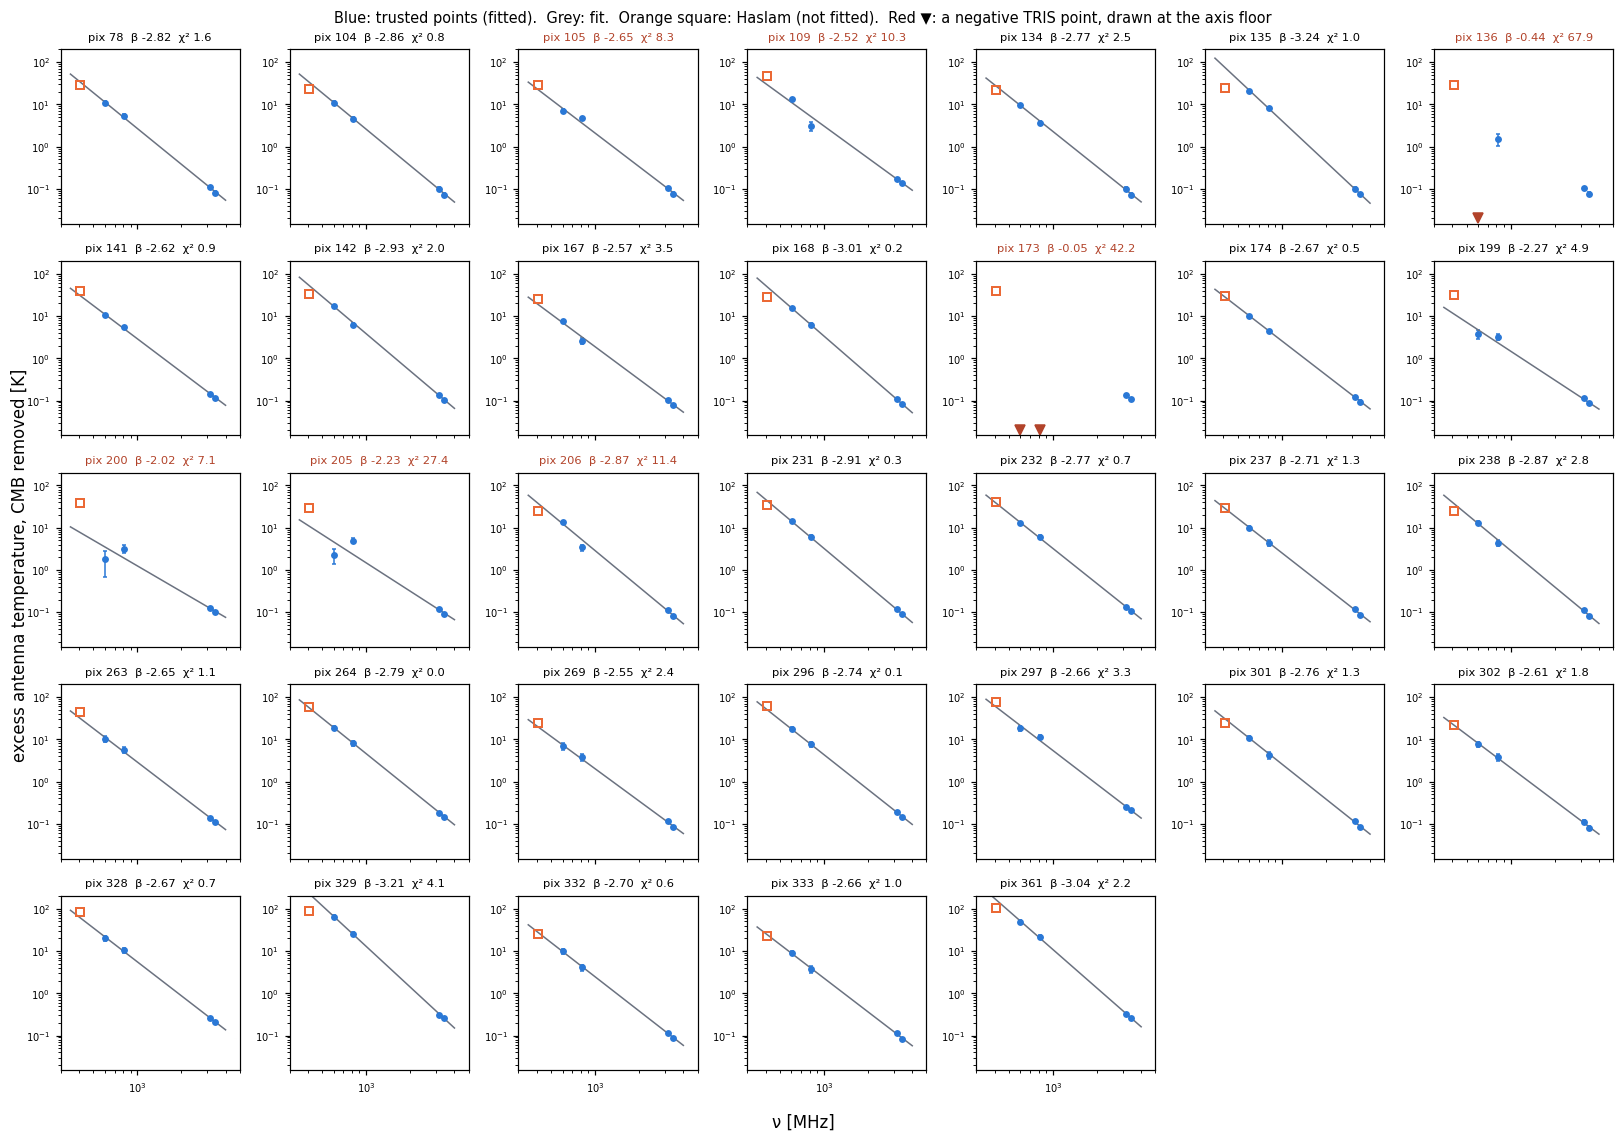

In [6]:
fig, axes = plt.subplots(5, 7, figsize=(15, 10.5), sharex=True)
grid = np.geomspace(350, 4000, 100)
for ax, r in zip(axes.flat, FIT):
    ok = r["t"] > 0
    ax.errorbar(r["nu"][ok], r["t"][ok], yerr=r["s"][ok], fmt="o", ms=3.5, color="#2a78d6",
                elinewidth=1, capsize=1.5)
    if (~ok).any():
        ax.plot(r["nu"][~ok], np.full((~ok).sum(), 0.02), "v", color="#b2432a", ms=6)
    if r["positive"] and abs(r["beta"]) < 10:
        ax.plot(grid, power_law(grid, r["A"], r["beta"]), "-", color="#6b7280", lw=1)
    ax.plot(408, r["raw"] - CMB_408, "s", ms=5, mfc="none", mec="#eb6834", mew=1.3)
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylim(0.015, 200); ax.set_xlim(300, 5000)
    ax.set_title(f"pix {r['pix']}  β {r['beta']:.2f}  χ² {r['chi2']:.1f}", fontsize=7.5,
                 color="#b2432a" if (not r["positive"] or r["chi2"] > 6) else "k")
    ax.tick_params(labelsize=6.5)
for ax in axes.flat[len(FIT):]:
    ax.axis("off")
fig.supxlabel("ν [MHz]"); fig.supylabel("excess antenna temperature, CMB removed [K]")
fig.suptitle("Blue: trusted points (fitted).  Grey: fit.  Orange square: Haslam (not fitted).  "
             "Red ▼: a negative TRIS point, drawn at the axis floor", fontsize=9.5)
fig.tight_layout()
plt.show()

---
## 5. Why some pixels fail: the TRIS points, not the power law

The negative and non-monotonic SEDs all come from the TRIS points. The stage 1 map is a
**pixel-scale deconvolution**: 7.3° pixels solved from one 18°-beam ring against a prior.
Neighbouring pixels trade off against each other by several σ (notebook 03, the RA 300°
section). Haslam and ARCADE 2 were smoothed to the 23.366° target. The TRIS maps were
**not**, because stage 1's product was assumed to be "at the TRIS beam", and a
Wiener-filtered pixel map is not.

---
## 6. Sensitivity: the two upstream choices that move the answer

Two choices that are not stage 3's to make, each switched on and off:

* **ẑ added back or not** (see the conventions above);
* **TRIS left as the stage 1 pixel map, or smoothed to the same 23.366° target** with
  `smooth_to_target(native = 0)`, mask-aware on the band. Only the values change; the TRIS
  σ are left as they are, which overstates them after smoothing.

This is a diagnostic, not a pipeline change.

In [7]:
def tris_smoothed(with_z):
    out = {}
    for row, (nu, tr) in enumerate(TRIS8.items()):
        m = np.where(band, tr["with_z" if with_z else "sky_only"], hp.UNSEEN)
        out[nu] = smooth_to_target(m, 0.0, TARGET_FWHM_DEG, weight_mask=band)
    return out

CASES = {"stage 1 pixels + ẑ  (primary)": FIT,
         "stage 1 pixels, no ẑ": fit_all(with_z=False),
         "TRIS smoothed + ẑ": fit_all(tris_maps=tris_smoothed(True), with_z=True),
         "TRIS smoothed, no ẑ": fit_all(tris_maps=tris_smoothed(False), with_z=False)}
print(f"{'case':<32}{'neg. SEDs':>10}{'β median':>10}{'β out':>7}{'χ²/dof ≤1 / 1–3 / >3':>24}"
      f"{'median pred−raw':>18}")
for name, rows in CASES.items():
    s = summarise(rows, name)
    print(f"{name:<32}{s['negative']:10d}{s['beta_med']:10.3f}{s['beta_out']:7d}"
          f"{s['chi_le1']:>12d} / {s['chi_1_3']:2d} / {s['chi_3_10'] + s['chi_gt10']:2d}"
          f"{s['diff_med']:+11.2f} K ({100 * s['frac_med']:+.0f}%)")

case                             neg. SEDs  β median  β out    χ²/dof ≤1 / 1–3 / >3   median pred−raw
stage 1 pixels + ẑ  (primary)            2    -2.697      2          17 /  9 /  7      -1.06 K (-2%)
stage 1 pixels, no ẑ                     2    -2.612      3          17 /  8 /  8      -6.87 K (-19%)
TRIS smoothed + ẑ                        0    -2.818      0          33 /  0 /  0      +6.08 K (+21%)
TRIS smoothed, no ẑ                      0    -2.739      0          32 /  1 /  0      +0.16 K (+1%)


---
## Verdict: stop here, before stage 4

* **The fit runs, and in aggregate it looks plausible.** The median β is −2.70. Most
  pixels fit well: 17 of 33 have χ²/dof ≤ 1 and 9 more are between 1 and 3. The median
  predicted − raw, −1.1 K (−1.8%), lands inside the 0.91 K / 3% benchmarks.
* **At the pixel level it is not physically sensible yet.** Two pixels have a negative
  TRIS excess, which is impossible for sky emission, and fall far outside the β range.
  Five more fit poorly because the TRIS 600 and 820 MHz values are not consistent with
  each other. The pixel-to-pixel spread in pred/raw is 0.74–1.50 (16–84%). The poor fits here
  trace back to the TRIS inputs, not to spectral curvature in the sky.
* **The benchmark comparison cannot yet validate the pipeline.** The two upstream choices
  in section 6 each move the median by about 20%, several times the benchmarks. Two of
  the four cases land inside the benchmarks: the primary (−2%) and smoothed TRIS without ẑ
  (+1%). Matching the benchmark is therefore not evidence for either case.
* **What would fix it upstream.** Put TRIS on the same effective beam as everything else
  before it enters an SED. Smoothing it to the target removes every negative SED and
  every out-of-range β, and leaves no pixel with χ²/dof > 3. And settle the ẑ question
  from notebook 03, because at 408 MHz it is worth about 6–7 K.